In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pingouin openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 13.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import os
import re

In [6]:
base_path = "/content/drive/MyDrive/Thesis_Data_Final/Cleaned_CSVs/"

os.listdir(base_path)

['Block_Raw_Data - Block_2_clean.csv',
 'Block_Raw_Data - Block_3_clean.csv',
 'Block_Raw_Data - Block_1_clean.csv',
 'Block_Raw_Data - Block_4_clean.csv']

In [7]:
files = {

    1: base_path + "Block_Raw_Data - Block_1_clean.csv",

    2: base_path + "Block_Raw_Data - Block_2_clean.csv",

    3: base_path + "Block_Raw_Data - Block_3_clean.csv",

    4: base_path + "Block_Raw_Data - Block_4_clean.csv"

}

all_long = []

score_col_pattern = r"^S\d+_(Olmo2|Olmo3)_(Implicit|Explicit)_(Cognitive|Affective)$"

for block_num, file_path in files.items():
    df = pd.read_csv(file_path)

    df["block"] = block_num
    df["rater_id"] = [f"B{block_num}_R{i+1}" for i in range(len(df))]

    # Only real score columns, not StartDate or Status
    score_cols = [col for col in df.columns if re.match(score_col_pattern, col)]

    print(f"Block {block_num}: {len(score_cols)} score columns")

    long_df = df.melt(
        id_vars=["block", "rater_id"],
        value_vars=score_cols,
        var_name="item",
        value_name="score"
    )

    all_long.append(long_df)

long_data = pd.concat(all_long, ignore_index=True)

pattern = r"^(S\d+)_(Olmo2|Olmo3)_(Implicit|Explicit)_(Cognitive|Affective)$"
parsed = long_data["item"].str.extract(pattern)

long_data["scenario"] = parsed[0]
long_data["model"] = parsed[1]
long_data["explicitness"] = parsed[2]
long_data["dimension"] = parsed[3]

print(long_data.shape)
print(long_data.isna().sum())

long_data.head()

Block 1: 48 score columns
Block 2: 48 score columns
Block 3: 48 score columns
Block 4: 48 score columns
(768, 8)
block           0
rater_id        0
item            0
score           0
scenario        0
model           0
explicitness    0
dimension       0
dtype: int64


,block,rater_id,item,score,scenario,model,explicitness,dimension
0,1,B1_R1,S1_Olmo2_Implicit_Cognitive,1.0,S1,Olmo2,Implicit,Cognitive
1,1,B1_R2,S1_Olmo2_Implicit_Cognitive,4.0,S1,Olmo2,Implicit,Cognitive
2,1,B1_R3,S1_Olmo2_Implicit_Cognitive,2.0,S1,Olmo2,Implicit,Cognitive
3,1,B1_R4,S1_Olmo2_Implicit_Cognitive,7.0,S1,Olmo2,Implicit,Cognitive
4,1,B1_R1,S1_Olmo2_Implicit_Affective,1.0,S1,Olmo2,Implicit,Affective


In [8]:
output_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/combined_long_format.csv"

long_data.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/combined_long_format.csv


In [9]:
long_data["score"].describe()

,score
count,768.000000
mean,6.058594
std,2.382674
min,0.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,10.000000


In [10]:
avg_data = (
    long_data
    .groupby(["scenario", "model", "explicitness", "dimension"], as_index=False)
    ["score"]
    .mean()
)

print(avg_data.shape)
avg_data.head()

(192, 5)


,scenario,model,explicitness,dimension,score
0,S1,Olmo2,Explicit,Affective,3.75
1,S1,Olmo2,Explicit,Cognitive,4.75
2,S1,Olmo2,Implicit,Affective,2.00
3,S1,Olmo2,Implicit,Cognitive,3.50
4,S1,Olmo3,Explicit,Affective,7.75


In [11]:
avg_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/averaged_scores_for_anova.csv"

avg_data.to_csv(avg_path, index=False)

print("Saved to:", avg_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/averaged_scores_for_anova.csv


In [12]:
# ICC per block and dimension: select ICC(A,k) = absolute agreement, average measures

icc_results = []

for block in sorted(long_data["block"].unique()):

    for dimension in ["Cognitive", "Affective"]:

        df_icc = long_data[

            (long_data["block"] == block) &

            (long_data["dimension"] == dimension)

        ].copy()

        df_icc["target"] = df_icc["item"]

        icc = pg.intraclass_corr(

            data=df_icc,

            targets="target",

            raters="rater_id",

            ratings="score"

        )

        selected = icc[icc["Type"] == "ICC(A,k)"].iloc[0]

        icc_results.append({

            "block": block,

            "dimension": dimension,

            "ICC_type": "ICC(A,k)",

            "ICC": selected["ICC"],

            "F": selected["F"],

            "pval": selected["pval"],

            "CI95": selected["CI95"]

        })

icc_table = pd.DataFrame(icc_results)

icc_table

,block,dimension,ICC_type,ICC,F,pval,CI95
0,1,Cognitive,"ICC(A,k)",0.571960,2.286499,4.443212e-03,"[0.19, 0.8]"
1,1,Affective,"ICC(A,k)",0.780454,4.475637,6.841547e-07,"[0.59, 0.9]"
2,2,Cognitive,"ICC(A,k)",0.275707,1.492043,1.035205e-01,"[-0.18, 0.62]"
3,2,Affective,"ICC(A,k)",0.484022,1.910942,2.069070e-02,"[0.03, 0.76]"
4,3,Cognitive,"ICC(A,k)",0.361137,2.024931,1.304472e-02,"[-0.01, 0.66]"
5,3,Affective,"ICC(A,k)",0.736269,4.893391,1.482091e-07,"[0.49, 0.88]"
6,4,Cognitive,"ICC(A,k)",0.162213,1.220034,2.588829e-01,"[-0.43, 0.58]"
7,4,Affective,"ICC(A,k)",0.519234,2.441670,2.330166e-03,"[0.16, 0.76]"


In [ ]:
icc_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ICC_results.csv"

icc_table.to_csv(icc_path, index=False)

print("Saved to:", icc_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ICC_results.csv


In [ ]:
# Descriptive statistics: means and standard deviations per condition

desc_table = (
    avg_data
    .groupby(["dimension", "model", "explicitness"])
    .agg(
        mean_score=("score", "mean"),
        sd_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
)

desc_table

,dimension,model,explicitness,mean_score,sd_score,n
0,Affective,Olmo2,Explicit,5.375000,1.371289,24
1,Affective,Olmo2,Implicit,4.166667,1.334465,24
2,Affective,Olmo3,Explicit,7.218750,1.365953,24
3,Affective,Olmo3,Implicit,6.260417,1.288492,24
4,Cognitive,Olmo2,Explicit,6.312500,1.189286,24
5,Cognitive,Olmo2,Implicit,5.447917,1.281090,24
6,Cognitive,Olmo3,Explicit,7.312500,1.030117,24
7,Cognitive,Olmo3,Implicit,6.375000,1.005420,24


In [ ]:
desc_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/descriptive_means.csv"

desc_table.to_csv(desc_path, index=False)

print("Saved to:", desc_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/descriptive_means.csv


In [ ]:
# Repeated-measures ANOVA for Cognitive and Affective empathy

cognitive_data = avg_data[avg_data["dimension"] == "Cognitive"].copy()
affective_data = avg_data[avg_data["dimension"] == "Affective"].copy()

anova_cognitive = pg.rm_anova(
    data=cognitive_data,
    dv="score",
    within=["model", "explicitness"],
    subject="scenario",
    detailed=True
)

anova_affective = pg.rm_anova(
    data=affective_data,
    dv="score",
    within=["model", "explicitness"],
    subject="scenario",
    detailed=True
)

print("Cognitive empathy ANOVA")
display(anova_cognitive)

print("Affective empathy ANOVA")
display(anova_affective)

Cognitive empathy ANOVA


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,model,22.281901,1,23,22.281901,18.211947,0.000289,0.000289,0.158910,1.0
1,explicitness,19.485026,1,23,19.485026,28.343023,0.000021,0.000021,0.141792,1.0
2,model * explicitness,0.031901,1,23,0.031901,0.019526,0.890086,0.890086,0.000270,1.0


Affective empathy ANOVA


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,model,93.023438,1,23,93.023438,78.045312,7.505636e-09,7.505636e-09,0.360094,1.0
1,explicitness,28.166667,1,23,28.166667,18.238123,2.868415e-04,2.868415e-04,0.145584,1.0
2,model * explicitness,0.375000,1,23,0.375000,0.175796,6.789013e-01,6.789013e-01,0.002263,1.0


In [ ]:
anova_cog_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ANOVA_cognitive.csv"
anova_aff_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ANOVA_affective.csv"

anova_cognitive.to_csv(anova_cog_path, index=False)
anova_affective.to_csv(anova_aff_path, index=False)

print("Saved cognitive ANOVA to:", anova_cog_path)
print("Saved affective ANOVA to:", anova_aff_path)

Saved cognitive ANOVA to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ANOVA_cognitive.csv
Saved affective ANOVA to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/ANOVA_affective.csv


In [ ]:
# Normality checks for ANOVA difference scores

# Cognitive wide
cog_wide = cognitive_data.pivot_table(
    index="scenario",
    columns=["model", "explicitness"],
    values="score"
)

# Affective wide
aff_wide = affective_data.pivot_table(
    index="scenario",
    columns=["model", "explicitness"],
    values="score"
)

# Difference scores for cognitive
cog_model_diff = cog_wide["Olmo3"].mean(axis=1) - cog_wide["Olmo2"].mean(axis=1)
cog_explicit_diff = cog_wide.xs("Explicit", level="explicitness", axis=1).mean(axis=1) - cog_wide.xs("Implicit", level="explicitness", axis=1).mean(axis=1)

# Difference scores for affective
aff_model_diff = aff_wide["Olmo3"].mean(axis=1) - aff_wide["Olmo2"].mean(axis=1)
aff_explicit_diff = aff_wide.xs("Explicit", level="explicitness", axis=1).mean(axis=1) - aff_wide.xs("Implicit", level="explicitness", axis=1).mean(axis=1)

normality_checks = pd.DataFrame({
    "check": [
        "Cognitive model difference",
        "Cognitive explicitness difference",
        "Affective model difference",
        "Affective explicitness difference"
    ],
    "shapiro_p": [
        pg.normality(cog_model_diff)["pval"].iloc[0],
        pg.normality(cog_explicit_diff)["pval"].iloc[0],
        pg.normality(aff_model_diff)["pval"].iloc[0],
        pg.normality(aff_explicit_diff)["pval"].iloc[0]
    ]
})

normality_checks

,check,shapiro_p
0,Cognitive model difference,0.526176
1,Cognitive explicitness difference,0.068166
2,Affective model difference,0.990206
3,Affective explicitness difference,0.369187


In [ ]:
normality_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/normality_checks.csv"

normality_checks.to_csv(normality_path, index=False)

print("Saved to:", normality_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/normality_checks.csv


In [ ]:
# Paired t-tests: Cognitive vs Affective within each model

wide_dim = avg_data.pivot_table(
    index=["scenario", "model", "explicitness"],
    columns="dimension",
    values="score"
).reset_index()

# OLMo-2
olmo2 = wide_dim[wide_dim["model"] == "Olmo2"]

ttest_olmo2 = pg.ttest(
    olmo2["Cognitive"],
    olmo2["Affective"],
    paired=True
)

ttest_olmo2["model"] = "Olmo2"
ttest_olmo2["n_pairs"] = len(olmo2)

# OLMo-3
olmo3 = wide_dim[wide_dim["model"] == "Olmo3"]

ttest_olmo3 = pg.ttest(
    olmo3["Cognitive"],
    olmo3["Affective"],
    paired=True
)

ttest_olmo3["model"] = "Olmo3"
ttest_olmo3["n_pairs"] = len(olmo3)

ttest_results = pd.concat([ttest_olmo2, ttest_olmo3], ignore_index=True)

ttest_results

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10,model,n_pairs
0,11.173708,47,two-sided,7.904332e-15,"[0.91, 1.31]",0.799520,0.999733,8.808e+11,Olmo2,48
1,0.748191,47,two-sided,4.580724e-01,"[-0.18, 0.38]",0.082372,0.086512,0.204,Olmo3,48


In [ ]:
# Show p-values in normal decimal format
ttest_display = ttest_results.copy()

ttest_display["p_val_decimal"] = ttest_display["p_val"].apply(lambda p: f"{p:.15f}")
ttest_display["p_report"] = ttest_display["p_val"].apply(lambda p: "p < .001" if p < .001 else f"p = {p:.3f}")

ttest_display[["model", "T", "dof", "p_val", "p_val_decimal", "p_report", "cohen_d", "n_pairs"]]

,model,T,dof,p_val,p_val_decimal,p_report,cohen_d,n_pairs
0,Olmo2,11.173708,47,7.904332e-15,0.000000000000008,p < .001,0.799520,48
1,Olmo3,0.748191,47,4.580724e-01,0.458072406230794,p = 0.458,0.082372,48


In [ ]:
ttest_path = "/content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/paired_ttests_cognitive_vs_affective.csv"

ttest_results.to_csv(ttest_path, index=False)

print("Saved to:", ttest_path)

Saved to: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/paired_ttests_cognitive_vs_affective.csv


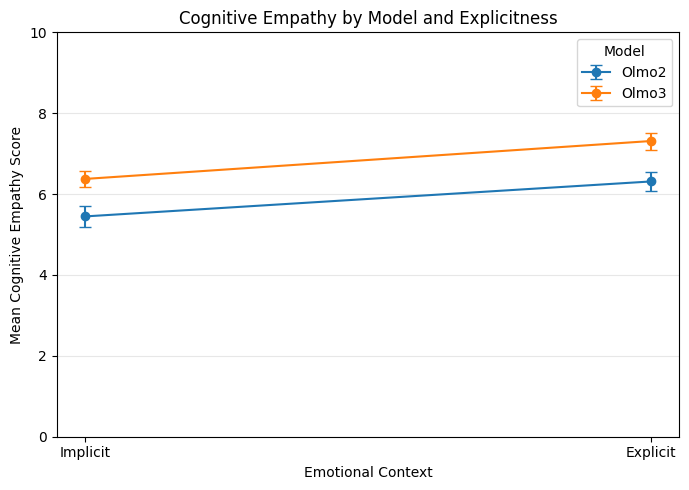

In [ ]:
# Figure 1: Cognitive empathy by model and explicitness

plot_path = "/content/drive/MyDrive/Thesis_Data_Final/Plots/"

cog_plot = desc_table[desc_table["dimension"] == "Cognitive"].copy()
cog_plot["se_score"] = cog_plot["sd_score"] / np.sqrt(cog_plot["n"])

explicitness_order = ["Implicit", "Explicit"]
models = ["Olmo2", "Olmo3"]

plt.figure(figsize=(7, 5))

for model in models:
    model_data = (
        cog_plot[cog_plot["model"] == model]
        .set_index("explicitness")
        .loc[explicitness_order]
        .reset_index()
    )

    plt.errorbar(
        model_data["explicitness"],
        model_data["mean_score"],
        yerr=model_data["se_score"],
        marker="o",
        capsize=4,
        label=model
    )

plt.title("Cognitive Empathy by Model and Explicitness")
plt.xlabel("Emotional Context")
plt.ylabel("Mean Cognitive Empathy Score")
plt.ylim(0, 10)
plt.legend(title="Model")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(plot_path + "figure1_cognitive_empathy_lineplot.png", dpi=300)
plt.show()

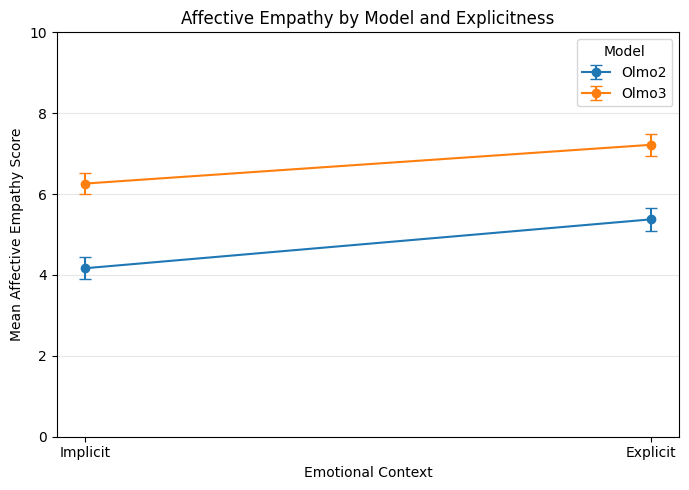

In [ ]:
# Figure 2: Affective empathy by model and explicitness

plot_path = "/content/drive/MyDrive/Thesis_Data_Final/Plots/"

aff_plot = desc_table[desc_table["dimension"] == "Affective"].copy()
aff_plot["se_score"] = aff_plot["sd_score"] / np.sqrt(aff_plot["n"])

explicitness_order = ["Implicit", "Explicit"]
models = ["Olmo2", "Olmo3"]

plt.figure(figsize=(7, 5))

for model in models:
    model_data = (
        aff_plot[aff_plot["model"] == model]
        .set_index("explicitness")
        .loc[explicitness_order]
        .reset_index()
    )

    plt.errorbar(
        model_data["explicitness"],
        model_data["mean_score"],
        yerr=model_data["se_score"],
        marker="o",
        capsize=4,
        label=model
    )

plt.title("Affective Empathy by Model and Explicitness")
plt.xlabel("Emotional Context")
plt.ylabel("Mean Affective Empathy Score")
plt.ylim(0, 10)
plt.legend(title="Model")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(plot_path + "figure2_affective_empathy_lineplot.png", dpi=300)
plt.show()

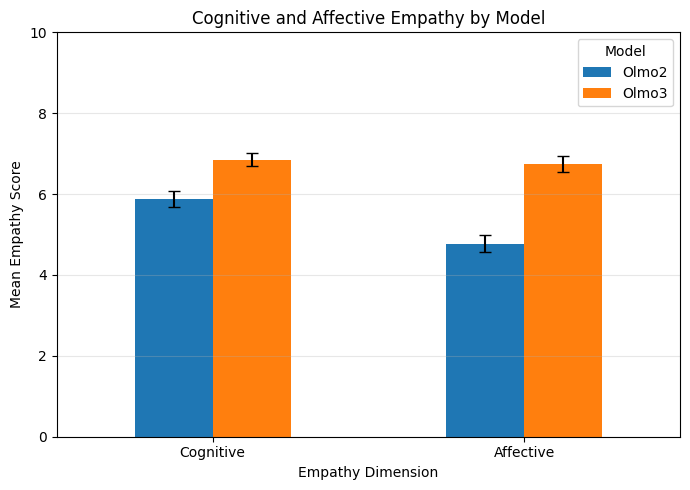

In [ ]:
# Figure 3: Cognitive vs affective empathy by model

plot_path = "/content/drive/MyDrive/Thesis_Data_Final/Plots/"

dimension_model_table = (
    avg_data
    .groupby(["model", "dimension"])
    .agg(
        mean_score=("score", "mean"),
        sd_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
)

dimension_model_table["se_score"] = (
    dimension_model_table["sd_score"] / np.sqrt(dimension_model_table["n"])
)

dim_pivot_mean = dimension_model_table.pivot(
    index="dimension",
    columns="model",
    values="mean_score"
).loc[["Cognitive", "Affective"]]

dim_pivot_se = dimension_model_table.pivot(
    index="dimension",
    columns="model",
    values="se_score"
).loc[["Cognitive", "Affective"]]

ax = dim_pivot_mean.plot(
    kind="bar",
    yerr=dim_pivot_se,
    capsize=4,
    figsize=(7, 5)
)

ax.set_title("Cognitive and Affective Empathy by Model")
ax.set_xlabel("Empathy Dimension")
ax.set_ylabel("Mean Empathy Score")
ax.set_ylim(0, 10)
ax.legend(title="Model")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(plot_path + "figure3_cognitive_vs_affective_by_model.png", dpi=300)
plt.show()

In [14]:
# Descriptive valence check
# Descriptive only: no new statistical test

import os

target_file = "averaged_scores_for_anova.csv"
found_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

if found_path is None:
    raise FileNotFoundError(f"{target_file} was not found in Google Drive.")

print("Using file:", found_path)
scores = pd.read_csv(found_path)

scores.columns = scores.columns.str.strip().str.lower().str.replace(" ", "_")

# Scenario valence mapping based on the scenario materials
valence_map = {
    "S1": "Negative", "S2": "Positive",
    "S3": "Negative", "S4": "Positive",
    "S5": "Negative", "S6": "Positive",
    "S7": "Negative", "S8": "Positive",
    "S9": "Negative", "S10": "Positive",
    "S11": "Negative", "S12": "Positive",
    "S13": "Negative", "S14": "Positive",
    "S15": "Negative", "S16": "Positive",
    "S17": "Negative", "S18": "Positive",
    "S19": "Negative", "S20": "Positive",
    "S21": "Negative", "S22": "Positive",
    "S23": "Negative", "S24": "Positive",
}

# Add valence column
scores["valence"] = scores["scenario"].map(valence_map)

# Check that all scenarios were mapped
print("Scenario valence mapping:")
display(scores[["scenario", "valence"]].drop_duplicates().sort_values("scenario"))

print("Valence counts:")
print(scores["valence"].value_counts())

# Mean scores by valence and explicitness
valence_overall = (
    scores.groupby(["valence", "explicitness"])["score"]
    .mean()
    .round(2)
    .reset_index(name="mean_score")
)

display(valence_overall)

# Mean scores by valence, empathy dimension, and explicitness
valence_dimension = (
    scores.groupby(["valence", "dimension", "explicitness"])["score"]
    .mean()
    .round(2)
    .reset_index(name="mean_score")
)

display(valence_dimension)

Using file: /content/drive/MyDrive/Thesis_Data_Final/Analysis_Output/averaged_scores_for_anova.csv
Scenario valence mapping:


,scenario,valence
0,S1,Negative
8,S10,Positive
16,S11,Negative
24,S12,Positive
32,S13,Negative
40,S14,Positive
48,S15,Negative
56,S16,Positive
64,S17,Negative
72,S18,Positive


Valence counts:
valence
Negative    96
Positive    96
Name: count, dtype: int64


,valence,explicitness,mean_score
0,Negative,Explicit,6.43
1,Negative,Implicit,5.41
2,Positive,Explicit,6.68
3,Positive,Implicit,5.71


,valence,dimension,explicitness,mean_score
0,Negative,Affective,Explicit,6.12
1,Negative,Affective,Implicit,5.01
2,Negative,Cognitive,Explicit,6.74
3,Negative,Cognitive,Implicit,5.81
4,Positive,Affective,Explicit,6.47
5,Positive,Affective,Implicit,5.42
6,Positive,Cognitive,Explicit,6.89
7,Positive,Cognitive,Implicit,6.01
